<div style="text-align: center;">

# Social Network Analysis (CS342) | Assignment 7

## **HITS (Hyperlink-Induced Topic Search) Algorithm**

---

**Student Name:** *Naishadh Rana*

**Roll No:** U23CS014

---

</div>


**Part I - HITS on two datasets**
- Implement HITS algorithm from scratch
- Use Karate Club graph and extended SVNIT web graph as base sets
- Find highest and lowest hub/authority scores

**Part II - Analysis**
- Compare behavior on social vs web graph
- Highlight key hub and authority URLs in SVNIT graph


**Required Libraries:** `networkx`, `matplotlib`, `requests`, `beautifulsoup4`


In [7]:
import time
from collections import deque
from urllib.parse import urljoin, urlparse, urldefrag

import requests
from bs4 import BeautifulSoup
import networkx as nx
import matplotlib.pyplot as plt

print("Imported")


Imported


## HITS Algorithm

HITS gives two scores for each node:
- **Hub score**: points to good authorities
- **Authority score**: pointed to by good hubs

Update rules:

$$a(v) = \sum_{u \rightarrow v} h(u), \quad h(v) = \sum_{v \rightarrow w} a(w)$$

After each update, normalize vectors so values don't explode.


In [8]:
# helper functions for crawling
def normalize_url(url, base="https://www.svnit.ac.in/"):
    if not url:
        return None
    url = urljoin(base, url)
    url, _ = urldefrag(url)
    return url


def is_same_domain(url, domain="svnit.ac.in"):
    try:
        return urlparse(url).netloc.lower().endswith(domain)
    except:
        return False


def is_html_like(url):
    skip = (
        ".pdf", ".jpg", ".jpeg", ".png", ".gif", ".svg",
        ".doc", ".docx", ".xls", ".xlsx", ".ppt", ".pptx",
        ".zip", ".rar", ".7z"
    )
    path = urlparse(url).path.lower()
    return not any(path.endswith(ext) for ext in skip)


def extract_links(html, base_url):
    soup = BeautifulSoup(html, "html.parser")
    links = []
    for a in soup.find_all("a", href=True):
        link = normalize_url(a.get("href"), base=base_url)
        if link:
            links.append(link)
    return links


def crawl_svnit(seed_url="https://www.svnit.ac.in/", max_pages=90, max_depth=3, request_timeout=15, sleep_sec=0.1):
    g = nx.DiGraph()
    visited = set()
    q = deque([(seed_url, 0)])

    while q and len(visited) < max_pages:
        url, depth = q.popleft()
        if url in visited or depth > max_depth:
            continue

        g.add_node(url)

        try:
            resp = requests.get(url, timeout=request_timeout, headers={"User-Agent": "SNA-Lab7"})
            if resp.status_code != 200:
                visited.add(url)
                continue
            html = resp.text
        except Exception:
            visited.add(url)
            continue

        visited.add(url)
        links = extract_links(html, url)

        for link in links:
            if is_same_domain(link) and is_html_like(link):
                g.add_edge(url, link)
                if link not in visited and depth + 1 <= max_depth:
                    q.append((link, depth + 1))

        time.sleep(sleep_sec)

    return g


def hits_custom(G, max_iter=200, tol=1e-8):
    if G.number_of_nodes() == 0:
        return {}, {}

    nodes = list(G.nodes())
    h = {n: 1.0 for n in nodes}
    a = {n: 1.0 for n in nodes}

    for _ in range(max_iter):
        new_a = {}
        for v in nodes:
            new_a[v] = sum(h[u] for u in G.predecessors(v))

        norm_a = sum(x * x for x in new_a.values()) ** 0.5
        if norm_a == 0:
            norm_a = 1.0
        for v in nodes:
            new_a[v] /= norm_a

        new_h = {}
        for v in nodes:
            new_h[v] = sum(new_a[w] for w in G.successors(v))

        norm_h = sum(x * x for x in new_h.values()) ** 0.5
        if norm_h == 0:
            norm_h = 1.0
        for v in nodes:
            new_h[v] /= norm_h

        diff = sum(abs(new_h[v] - h[v]) + abs(new_a[v] - a[v]) for v in nodes)
        h, a = new_h, new_a
        if diff < tol:
            break

    return h, a


In [9]:
# dataset 1: Karate Club
K = nx.karate_club_graph().to_directed()
h_k, a_k = hits_custom(K)

high_h_k = max(h_k, key=h_k.get)
high_a_k = max(a_k, key=a_k.get)
low_h_k = min(h_k, key=h_k.get)
low_a_k = min(a_k, key=a_k.get)

print("Karate Club graph")
print("-" * 32)
print(f"Highest hub node: {high_h_k} ({h_k[high_h_k]:.6f})")
print(f"Highest authority node: {high_a_k} ({a_k[high_a_k]:.6f})")
print(f"Lowest hub node: {low_h_k} ({h_k[low_h_k]:.6f})")
print(f"Lowest authority node: {low_a_k} ({a_k[low_a_k]:.6f})")

print("\nTop 5 hubs:")
for node, s in sorted(h_k.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  {node:>2}: {s:.6f}")

print("\nTop 5 authorities:")
for node, s in sorted(a_k.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  {node:>2}: {s:.6f}")


Karate Club graph
--------------------------------
Highest hub node: 33 (0.373363)
Highest authority node: 33 (0.373363)
Lowest hub node: 16 (0.023636)
Lowest authority node: 16 (0.023636)

Top 5 hubs:
  33: 0.373363
   0: 0.355491
   2: 0.317193
  32: 0.308644
   1: 0.265960

Top 5 authorities:
  33: 0.373363
   0: 0.355491
   2: 0.317193
  32: 0.308644
   1: 0.265960


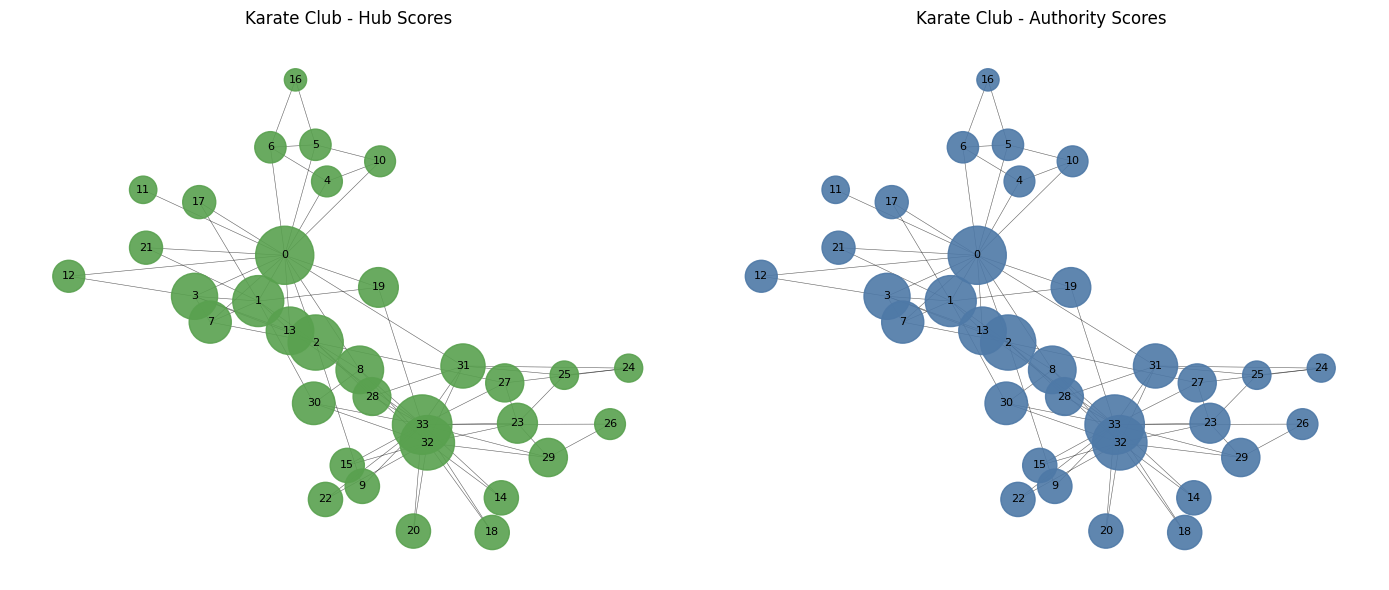

In [10]:
# visualize Karate Club by hub and authority
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
pos = nx.spring_layout(K, seed=42)

hub_sizes = [4500 * h_k[n] + 150 for n in K.nodes()]
auth_sizes = [4500 * a_k[n] + 150 for n in K.nodes()]

nx.draw_networkx_nodes(K, pos, node_size=hub_sizes, node_color="#59A14F", alpha=0.9, ax=axes[0])
nx.draw_networkx_edges(K, pos, width=0.4, alpha=0.35, arrows=False, ax=axes[0])
nx.draw_networkx_labels(K, pos, font_size=8, ax=axes[0])
axes[0].set_title("Karate Club - Hub Scores")
axes[0].axis("off")

nx.draw_networkx_nodes(K, pos, node_size=auth_sizes, node_color="#4E79A7", alpha=0.9, ax=axes[1])
nx.draw_networkx_edges(K, pos, width=0.4, alpha=0.35, arrows=False, ax=axes[1])
nx.draw_networkx_labels(K, pos, font_size=8, ax=axes[1])
axes[1].set_title("Karate Club - Authority Scores")
axes[1].axis("off")

plt.tight_layout()
plt.show()


In [11]:
# dataset 2: Extended SVNIT web graph
G_ext = crawl_svnit(max_pages=90, max_depth=3)

n = G_ext.number_of_nodes()
m = G_ext.number_of_edges()

print(f"Extended SVNIT graph nodes: {n}")
print(f"Extended SVNIT graph edges: {m}")

h_w, a_w = hits_custom(G_ext)

if h_w and a_w:
    high_h_w = max(h_w, key=h_w.get)
    high_a_w = max(a_w, key=a_w.get)
    low_h_w = min(h_w, key=h_w.get)
    low_a_w = min(a_w, key=a_w.get)

    print("\nExtended SVNIT graph")
    print("-" * 32)
    print(f"Highest hub URL: {high_h_w}")
    print(f"Hub score: {h_w[high_h_w]:.6f}")
    print(f"Highest authority URL: {high_a_w}")
    print(f"Authority score: {a_w[high_a_w]:.6f}")
    print(f"Lowest hub URL: {low_h_w}")
    print(f"Hub score: {h_w[low_h_w]:.6f}")
    print(f"Lowest authority URL: {low_a_w}")
    print(f"Authority score: {a_w[low_a_w]:.6f}")

    print("\nTop 10 hubs:")
    for url, s in sorted(h_w.items(), key=lambda x: x[1], reverse=True)[:10]:
        print(f"{s:.6f}  {url}")

    print("\nTop 10 authorities:")
    for url, s in sorted(a_w.items(), key=lambda x: x[1], reverse=True)[:10]:
        print(f"{s:.6f}  {url}")
else:
    print("Graph is empty")


Extended SVNIT graph nodes: 535
Extended SVNIT graph edges: 5753

Extended SVNIT graph
--------------------------------
Highest hub URL: https://www.svnit.ac.in/
Hub score: 0.111765
Highest authority URL: https://help.ccc.svnit.ac.in
Authority score: 0.128290
Lowest hub URL: https://mis.svnit.ac.in/SVNIT/
Hub score: 0.000000
Lowest authority URL: https://mis.svnit.ac.in/mispay/default.aspx
Authority score: 0.000000

Top 10 hubs:
0.111765  https://www.svnit.ac.in/
0.111743  https://www.svnit.ac.in/index.php
0.110351  https://www.svnit.ac.in/web/student_notice.php
0.109353  https://www.svnit.ac.in/web/admission.php
0.109224  https://www.svnit.ac.in/web/department/Electronics/
0.109076  https://www.svnit.ac.in/web/department/chemical/
0.109076  https://www.svnit.ac.in/web/department/Electrical/
0.109076  https://www.svnit.ac.in/web/department/physics/
0.109033  https://www.svnit.ac.in/web/department/maths/
0.108991  https://www.svnit.ac.in/web/department/civil/

Top 10 authorities:
0.1282

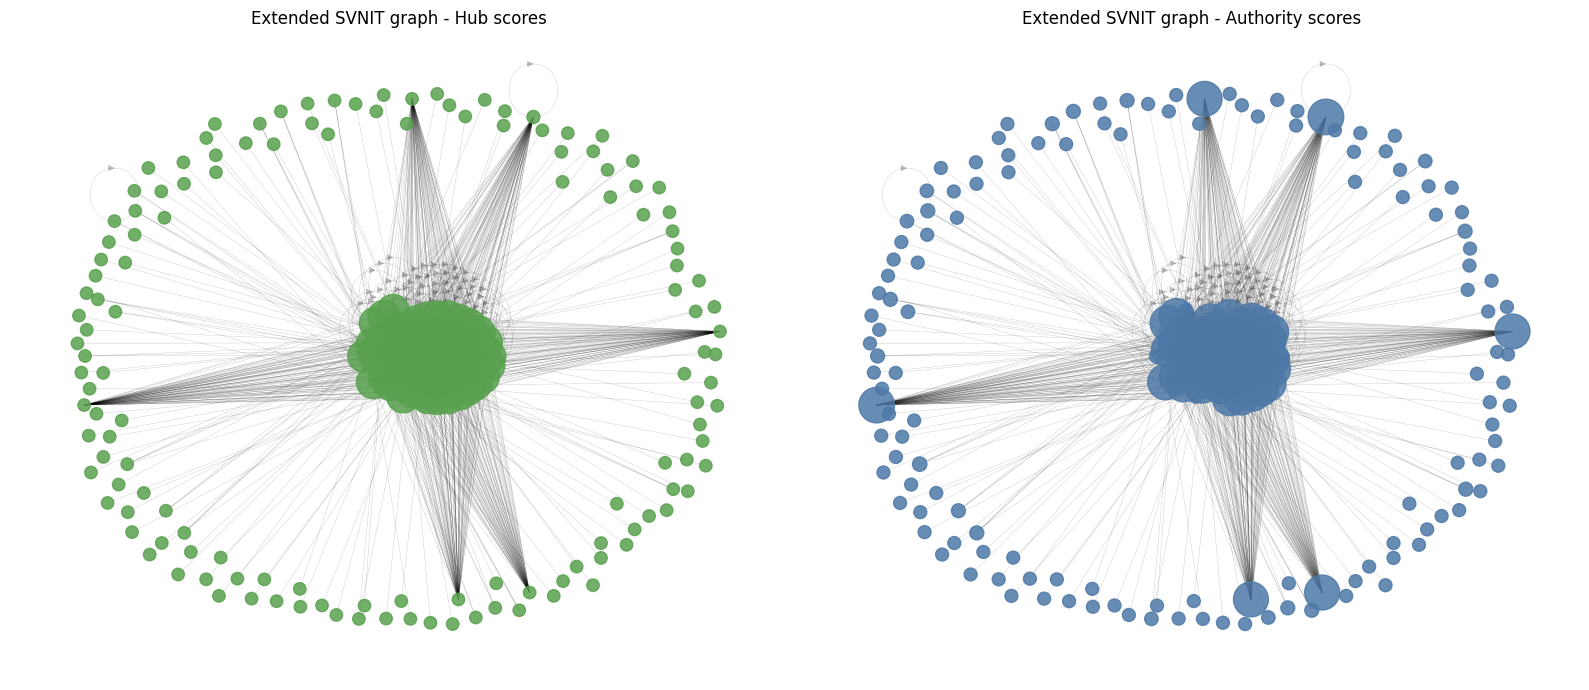

In [12]:
# visualize sampled extended graph with hub/authority emphasis
if n > 0:
    sample_nodes = list(G_ext.nodes())[:220]
    H = G_ext.subgraph(sample_nodes).copy()
    pos = nx.spring_layout(H, seed=42, k=0.6)

    hub_sizes = [4500 * h_w.get(node, 0) + 80 for node in H.nodes()]
    auth_sizes = [4500 * a_w.get(node, 0) + 80 for node in H.nodes()]

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    nx.draw_networkx_nodes(H, pos, node_size=hub_sizes, node_color="#59A14F", alpha=0.85, ax=axes[0])
    nx.draw_networkx_edges(H, pos, width=0.25, alpha=0.25, arrows=False, ax=axes[0])
    axes[0].set_title("Extended SVNIT graph - Hub scores")
    axes[0].axis("off")

    nx.draw_networkx_nodes(H, pos, node_size=auth_sizes, node_color="#4E79A7", alpha=0.85, ax=axes[1])
    nx.draw_networkx_edges(H, pos, width=0.25, alpha=0.25, arrows=False, ax=axes[1])
    axes[1].set_title("Extended SVNIT graph - Authority scores")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()


### Findings

**Karate Club graph**
- Highest hub node: **33** (0.373363)
- Highest authority node: **33** (0.373363)
- Lowest hub node: **16** (0.023636)
- Lowest authority node: **16** (0.023636)
- Top 5 hubs/authorities were same in this run: **33, 0, 2, 32, 1**

**Extended SVNIT web graph**
- Nodes: **535**, Edges: **5753**
- Highest hub URL: **https://www.svnit.ac.in/** (0.111765)
- Highest authority URL: **https://help.ccc.svnit.ac.in** (0.128290)
- Lowest hub URL: **https://mis.svnit.ac.in/SVNIT/** (0.000000)
- Lowest authority URL: **https://mis.svnit.ac.in/mispay/default.aspx** (0.000000)

**Interesting observations**
- Pages with lots of outgoing links act as strong hubs.
- Pages referenced by many major pages act as strong authorities.
- In this run, HITS separated hub and authority roles more clearly in the web graph than in Karate Club.

**Dataset website details (as required)**
- Website name: **SVNIT**
- URL: **https://www.svnit.ac.in/**
